## Analyzing Wikipedia Data from S3 Bucket

Importing libraries

In [27]:
import pandas as pd
import boto3
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

Assignment example to verify data pull works

In [28]:
hour_df = pd.read_parquet("s3://dsan6000-wikipedia/hourly_parquet/20260901_040000.parquet")
hour_df.head(n = 1)

,datetime,$schema,meta,id,type,namespace,title,title_url,comment,timestamp,...,wiki,parsedcomment,log_id,log_type,log_action,log_params,log_action_comment,patrolled,file_ts,file_ts_str
0,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Jake_O%...,2.063884e+09,edit,0,Jake O'Donnell,https://en.wikipedia.org/wiki/Jake_O%27Donnell,Fix dash,1788235202,...,enwiki,Fix dash,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000


Reading in all .parquet files and combining into one df

In [ ]:
# setting up data and S3 initializations from my bucket
s3 = boto3.client("s3")
bucket_name = "dsan6000-sg1951"
response = s3.list_objects_v2(Bucket = bucket_name)

# looping through each file, converting to df, joining at end
datatables = []
for item in response["Contents"]:
    key = item["Key"]
    df = pd.read_parquet(f"s3://{bucket_name}/{key}")
    datatables.append(df)

# concatenating all dfs
joint_wiki = pd.concat(datatables, ignore_index = True)
print(joint_wiki.head(n = 1))
print(joint_wiki.shape)
print(print(joint_wiki.columns))

              datetime                        $schema  \
0  2026-09-01 04:00:02  /mediawiki/recentchange/1.0.0   

                                                meta            id  type  \
0  {'uri': 'https://en.wikipedia.org/wiki/Jake_O%...  2.063884e+09  edit   

   namespace           title                                       title_url  \
0          0  Jake O'Donnell  https://en.wikipedia.org/wiki/Jake_O%27Donnell   

    comment   timestamp  ...    wiki  parsedcomment log_id log_type  \
0  Fix dash  1788235202  ...  enwiki       Fix dash    NaN      NaN   

  log_action log_params log_action_comment patrolled              file_ts  \
0        NaN        NaN                NaN      None  2026-09-01 04:00:00   

       file_ts_str  
0  20260901_040000  

[1 rows x 29 columns]
(119708, 29)
Index(['datetime', '$schema', 'meta', 'id', 'type', 'namespace', 'title',
       'title_url', 'comment', 'timestamp', 'user', 'bot', 'notify_url',
       'minor', 'length', 'revision', 'server_ur

Plot 1: Total Number of Events per Hour

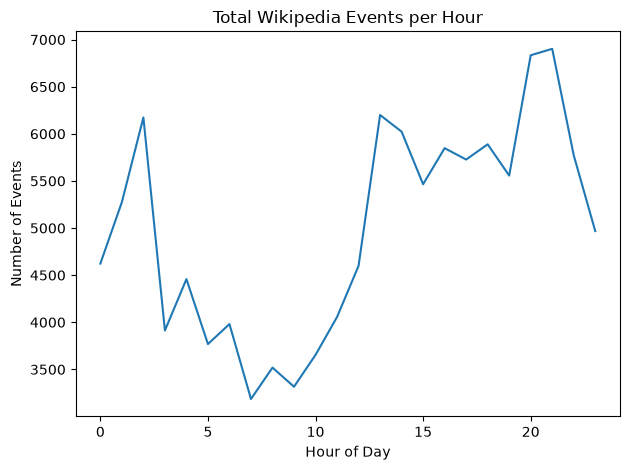

In [30]:
# making an hour column for each event
joint_wiki['datetime'] = pd.to_datetime(joint_wiki['datetime'])
joint_wiki['hour'] = joint_wiki['datetime'].dt.hour

# grouping by hour 
hourly_wiki = joint_wiki.groupby("hour").size().reset_index(name = "count")

# plotting
plt.figure()
sns.lineplot(data = hourly_wiki, x = "hour", y = "count")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Events")
plt.title("Total Wikipedia Events per Hour")
plt.tight_layout()

# saving plots to images/
plt.savefig("images/hourly-events.svg")
plt.savefig("images/hourly-events.png")

plt.show()

Plot 2: Hourly Event Counts by Type

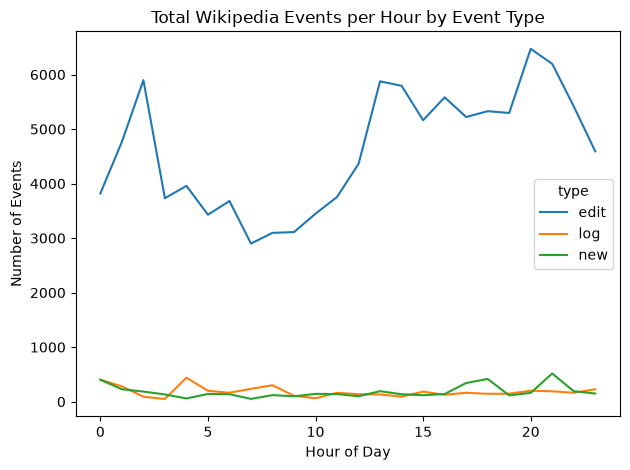

In [31]:
# using same hourly structure as previouse plot
joint_wiki['hour'] = joint_wiki['datetime'].dt.hour

# grouping by hour and type
hourly_type_wiki = joint_wiki.groupby(["hour", "type"]).size().reset_index(name = "count")

# plotting
plt.figure()
sns.lineplot(data = hourly_type_wiki, x = "hour", y = "count", hue = "type")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Events")
plt.title("Total Wikipedia Events per Hour by Event Type")
plt.tight_layout()

# saving plots to images/
plt.savefig("images/events-by-type.svg")
plt.savefig("images/events-by-type.png")

plt.show()